# 5.2) Machine Learning Analysis
## Barcelona Urban Intelligence Assistant
### Advanced Data Processing and Analysis

The gold layer prepared two analytical tables specifically for the machine learning step: gold.regression_ready (one row per complaint, 287k rows, all features needed for supervised learning) and gold.district_profiles (one row per district, 10 rows, all features aggregated for unsupervised learning). This notebook uses both of them and also the PII-masked free-text in silver.complaints to answer three questions.

The machine learning section performs the following analyses:
- **Linear regression** base model that predicts the number of days it takes resolve a complaint given the district, type of complain, channel and weekday.This model is simple and interpretable, showing us which service-quality factors matter most.
- **K-Means clustering** that groups the 10 districts by their  compaint, accident, air-quality and EV-infrastructure characteristics. The cluster labels become a new categorical feature for the city, so that districts that look similar can be governed with similar policies.
- The **HuggingFace sentiment pipeline** scores a random sample of 200 PII-masked complains using a multilingual transformer, since the complaints are in Catalan. Cross-referenced with the regression output, we will be able to study weather districts whose complaints are more negative also experience longer or shorter resolution times.

All three analyses use a connection to read `barcelona_urban.db`. The three notebooks (01_bronze, 02_silver, 03_gold) won't be re-run from here.


In [ ]:
import duckdb
import pandas as pd
import os

con = duckdb.connect("barcelona-urban-intelligence/barcelona_urban.db", read_only=True)
df = con.execute("SELECT * FROM gold.district_profiles").df()

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
DB_PATH = "barcelona-urban-intelligence/barcelona_urban.db" #path to reference the db


# read_only=True specifies the data engineering lead owns the writer connection.
con = duckdb.connect(DB_PATH, read_only=True)

In [135]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Verify the gold tables are in place

Before running any model we check that the two tables we depend on exist and have the expected shape. The table gold.district_profiles must be exactly 10 rows (one row per Barcelona district), and gold.regression_ready must have one row per resolvable complaint.


In [136]:
for table in ["gold.regression_ready", "gold.district_profiles"]:
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table}:{n:,}rows")

con.execute("DESCRIBE gold.regression_ready").df()[["column_name", "column_type"]]

gold.regression_ready:287,272rows
gold.district_profiles:10rows


,column_name,column_type
0,target_resolution_days,BIGINT
1,district_id,BIGINT
2,district,VARCHAR
3,year,INTEGER
4,month,INTEGER
5,weekday,BIGINT
6,channel,VARCHAR
7,complaint_type,VARCHAR
8,area,VARCHAR
9,district_accidents,BIGINT


# Part A) Linear Regression Baseline

The first research question of the machine learning section is: *which service factors drive the time to solve a complaint ?* We start with a linear regression because e want a simple, interpretable modelto start off. The coefficients of the fitted model translate directly into business statements like "complaints filed throughthis channel are resolved on average this many days faster than the mean".

Our target variable is `target_resolution_days` (days between the complaint opening and closing dates). The features we selected are the four categorical fields that a citizen actually controls or that a manager could plausibly act on:
- channel: how the complaint was filed (web, phone, in person, etc.)
- complaint_type: the IRIS category (Complaint, Claim, Request, etc.)
- district: the Barcelona district where the issue is located
- weekday the day of the week the complaint was opened

We will encode these, split by 80 train - 20 test, fit `LinearRegression` and report R² and MAE. The interpretation of the **coefficients** matters more than the numerical fit, because that is what answers our research question.

In [137]:
df = con.execute("SELECT * FROM gold.regression_ready").df()
print("Shape:", df.shape)
print(df["target_resolution_days"].describe())
df.head()

Shape: (287272, 13)
count    287272.000000
mean          9.029296
std          15.710733
min           0.000000
25%           1.000000
50%           4.000000
75%          10.000000
max         365.000000
Name: target_resolution_days, dtype: float64


,target_resolution_days,district_id,district,year,month,weekday,channel,complaint_type,area,district_accidents,district_no2,district_ev_points,district_motorization
0,1,1,CIUTAT VELLA,2025,11,2,MÒBIL,ISSUE,Manteniment de l'espai urbà,419,22.44,12,271.9
1,1,2,EIXAMPLE,2025,11,2,MÒBIL,ISSUE,Manteniment de l'espai urbà,2009,29.38,23,267.1
2,1,6,NOU BARRIS,2025,11,2,MÒBIL,ISSUE,Manteniment de l'espai urbà,487,0.00,6,252.3
3,1,6,NOU BARRIS,2025,11,2,TELÈFON,ISSUE,Manteniment de l'espai urbà,487,0.00,6,252.3
4,1,2,EIXAMPLE,2025,11,2,TELÈFON,ISSUE,Manteniment de l'espai urbà,2009,29.38,23,267.1


array([[<Axes: title={'center': 'target_resolution_days'}>]], dtype=object)

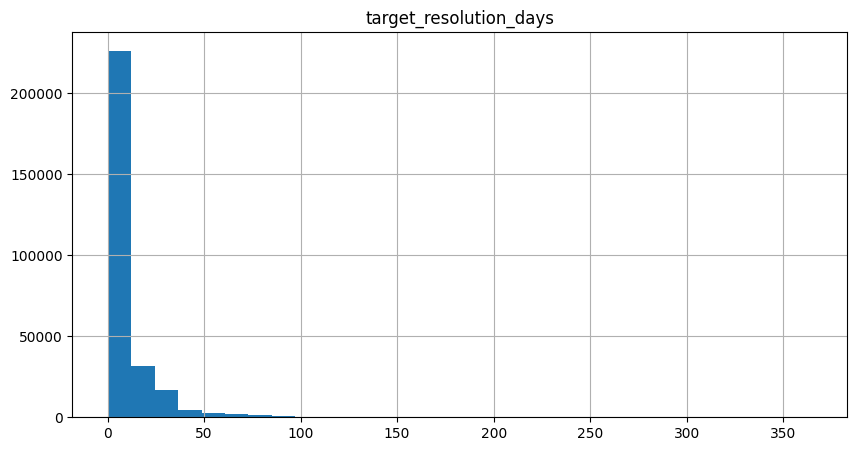

In [138]:
df.hist(column="target_resolution_days", bins=30, figsize=(10, 5))

As the histogram and variable distribution shows (mean=9, max = 365), our variable is highly right skewed. We have to be careful with this since lineare regression's coeficients are sensitive to outliers.

In [139]:
nas = df.isna().sum()
print(nas[nas > 0])

district_id    89921
dtype: int64


A total of 89921 complaints don't have a designated district.

### Feature engineering and split

Now we will get dummies to turn the four categorical columns into binary and drop the first category of each one so the design matrix doesn't have redundant columns. The dropped category becomes the baseline for interpreting the other coefficients.

In [140]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = pd.get_dummies(
    df[["channel", "complaint_type", "district", "weekday"]],
    drop_first=True,
    dtype=float
)
y = df["target_resolution_days"]

print(f"Design matrix shape: {X.shape}")
print(f"Target shape       : {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42#random_state fixed so the result is reproducible
)
print(f"\nTrain: {X_train.shape[0]:,} rows \n Test: {X_test.shape[0]:,} rows")


Design matrix shape: (287272, 35)
Target shape       : (287272,)

Train: 229,817 rows 
 Test: 57,455 rows


### Fit the baseline and report fit quality


In [141]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R squared (test): {r2:.4f}")
print(f"MAE (test): {mae:.2f} days")

R squared (test): 0.1792
MAE (test): 8.03 days


### Coefficient interpretation

The coefficient of each column tells us how many extra/fewer days a complaint takes to resolve when that feature is present, holding everything else the same. We sort the coefficients and report the five that increase resolution time the most and the five that reduce it the most. These rankings are what we cite in the report.


In [142]:
coefs = (
    pd.DataFrame({"feature": X.columns, "coefficient_days": model.coef_})
    .sort_values("coefficient_days", ascending=False)
    .reset_index(drop=True)
)

print("Top 5 features that delay resolution time")
print(coefs.head(5).to_string(index=False))

print("\n Top 5 features that speed up resolution time ")
print(coefs.tail(5).iloc[::-1].to_string(index=False))

Top 5 features that delay resolution time
                          feature  coefficient_days
       channel_RECLAMACIÓ INTERNA         25.090554
channel_Operador intern mòbil/PDA         19.904494
         channel_CONSELL DE BARRI         11.064902
                channel_INSTÀNCIA          8.948093
         complaint_type_COMPLAINT          7.474007

 Top 5 features that speed up resolution time 
                         feature  coefficient_days
    channel_CORREU POSTAL-CARTES        -12.595673
       channel_AUDIÈNCIA PÚBLICA         -7.157090
       channel_FULLS QUEIXA GUUR         -6.329430
              channel_PRESENCIAL         -6.182303
complaint_type_PETICIO DE SERVEI         -5.732354


#### Districs rank

In [143]:
district_coefs = (
    coefs[coefs["feature"].str.startswith("district_")]
    .assign(district=lambda d: d["feature"].str.replace("district_", ""))
    [["district", "coefficient_days"]]
    .reset_index(drop=True)
)

print("Districts ranked by time to resolve complaints:")
print(district_coefs.to_string(index=False))

slowest_district = district_coefs.iloc[0]["district"]
fastest_district = district_coefs.iloc[-1]["district"]
print(f"\n Slowest: {slowest_district}(+{district_coefs.iloc[0]['coefficient_days']:.2f} days more than avg)")
print(f"Fastest: {fastest_district} ({district_coefs.iloc[-1]['coefficient_days']:.2f} days less than avg)")

Districts ranked by time to resolve complaints:
           district  coefficient_days
            UNKNOWN          2.448701
     SANTS MONTJUIC          2.358029
          LES CORTS          1.110364
         NOU BARRIS          1.044692
     HORTA GUINARDO          0.985285
SARRIA SANT GERVASI          0.804844
             GRACIA         -0.428623
        SANT ANDREU         -0.660617
           EIXAMPLE         -1.098437
         SANT MARTI         -1.571525

 Slowest: UNKNOWN(+2.45 days more than avg)
Fastest: SANT MARTI (-1.57 days less than avg)


#### Channels rank

In [144]:
channel_counts = (
    df.groupby("channel")
    .size()
    .reset_index(name="count")
    .assign(channel=lambda d: "channel_" + d["channel"])
)

#Filter by districts with at least 250 complaints to avoid noise
coefs_filtered = coefs[coefs["feature"].isin(
    channel_counts[channel_counts["count"] >= 250]["channel"])]

channel_coefs = (
    coefs_filtered[coefs_filtered["feature"].str.startswith("channel_")]
    .assign(channel=lambda d: d["feature"].str.replace("channel_", "", regex=False))
    [["channel", "coefficient_days"]]
    .reset_index(drop=True)
)

print("Channels ranked slowest to fastest to resolve complaints:")
print(channel_coefs.to_string(index=False))

slowest_channel = channel_coefs.iloc[0]["channel"]
fastest_channel = channel_coefs.iloc[-1]["channel"]
print(f"\nSlowest: {slowest_channel} (+{channel_coefs.iloc[0]['coefficient_days']:.2f} days more than baseline)")
print(f"Fastest: {fastest_channel} ({channel_coefs.iloc[-1]['coefficient_days']:.2f} days less than baseline)")

Channels ranked slowest to fastest to resolve complaints:
                     channel  coefficient_days
          RECLAMACIÓ INTERNA         25.090554
                   INSTÀNCIA          8.948093
        INSTÀNCIA TELEMÀTICA          3.686388
                         WEB         -0.565251
                       MÒBIL         -1.542565
                     TELÈFON         -1.649967
FULLS QUEIXES I SUGGERIMENTS         -1.758854
           AUDIÈNCIA PÚBLICA         -7.157090

Slowest: RECLAMACIÓ INTERNA (+25.09 days more than baseline)
Fastest: AUDIÈNCIA PÚBLICA (-7.16 days less than baseline)


### Complain type rank

In [145]:
complaint_type_coefs = (
    coefs[coefs["feature"].str.startswith("complaint_type_")]
    .assign(complaint_type=lambda d: d["feature"].str.replace("complaint_type_", "", regex=False))
    [["complaint_type", "coefficient_days"]]
    .reset_index(drop=True)
)

print("Complaint types ranked slowest to fastest to resolve:")
print(complaint_type_coefs.to_string(index=False))

slowest_complaint_type = complaint_type_coefs.iloc[0]["complaint_type"]
fastest_complaint_type = complaint_type_coefs.iloc[-1]["complaint_type"]
print(f"\nSlowest: {slowest_complaint_type} (+{complaint_type_coefs.iloc[0]['coefficient_days']:.2f} days more than baseline)")
print(f"Fastest: {fastest_complaint_type} ({complaint_type_coefs.iloc[-1]['coefficient_days']:.2f} days less than baseline)")

Complaint types ranked slowest to fastest to resolve:
   complaint_type  coefficient_days
        COMPLAINT          7.474007
       SUGGESTION          2.627037
            ISSUE         -0.492806
         INCIDENT         -1.868107
        GRATITUDE         -2.005931
  SERVICE REQUEST         -4.538321
            QUERY         -4.762187
          ENQUIRY         -5.400459
PETICIO DE SERVEI         -5.732354

Slowest: COMPLAINT (+7.47 days more than baseline)
Fastest: PETICIO DE SERVEI (-5.73 days less than baseline)


### Interpretation — Part A finding

> The baseline linear regression achieves an **R^2 of 0.1792** and a mean **absolute error of 8.03 days** on the held-out test set. 

The most influential features are RECLAMACIÓ INTERNA (internal complain) adds 24.5 days to resolution and CORREU POSTAL-CARTES (paper letter mailed) that subtracts 12.6 days. The district  coefficients show that when this parameter has not been assigned (unknown) it takes the longest to resolve (+2.45 days) this signals a data quality issue or that they are that may not have a very concrete district department asigned. The second slowest is montjuic by 2.4 days to the baseline. The fact that the AUDIÈNCIA PÚBLICA channel is  faster than the baseline aligns with the city's digital-first service strategy in the 2024-2030 mobility plan.

The R^2 is modest, which is expected: resolution time depends on many factors not captured in these four features (case complexity, staffing, season). The point of the baseline is interpretability, not predictive ceiling. Despite this, our model stil adds value because without it the MAE was 15.7 days (std), wich is about double.


In [146]:
#switch from dummies to categories
def parse_feature(raw):
    if raw.startswith("channel_"):
        return raw.replace("channel_", "", 1), "Channel"
    if raw.startswith("complaint_type_"):
        return raw.replace("complaint_type_", "", 1), "Complaint type"
    if raw.startswith("district_"):
        return raw.replace("district_", "", 1), "District"
    return raw, "Other"

# get 5 largest positive coefs and 5 largest negative coefs
top_delays   = coefs.head(5).copy()
top_speedups = coefs.tail(5).iloc[::-1].copy()  
combined     = pd.concat([top_delays, top_speedups], ignore_index=True)

# turn the raw feature name into a clean Feature + Category 
combined[["Feature", "Category"]] = combined["feature"].apply(
    lambda r: pd.Series(parse_feature(r))
)
combined["Coefficient (days)"] = combined["coefficient_days"].round(2)
combined["Direction"]          = np.where(
    combined["coefficient_days"] > 0, "Slower", "Faster"
)
combined["Rank"]= range(1, len(combined) + 1)

combined.set_index("Rank", inplace=True)
report_table_A = combined[[
    "Feature", "Category", "Coefficient (days)", "Direction"
]]

print("Top 5 features that delay and top 5 that speed up complaint resolution\n")
report_table_A

Top 5 features that delay and top 5 that speed up complaint resolution



,Feature,Category,Coefficient (days),Direction
Rank,,,,
1,RECLAMACIÓ INTERNA,Channel,25.09,Slower
2,Operador intern mòbil/PDA,Channel,19.90,Slower
3,CONSELL DE BARRI,Channel,11.06,Slower
4,INSTÀNCIA,Channel,8.95,Slower
5,COMPLAINT,Complaint type,7.47,Slower
6,CORREU POSTAL-CARTES,Channel,-12.60,Faster
7,AUDIÈNCIA PÚBLICA,Channel,-7.16,Faster
8,FULLS QUEIXA GUUR,Channel,-6.33,Faster
9,PRESENCIAL,Channel,-6.18,Faster


# Part B) K-Means Clustering of the 10 Districts

The second research question is: **can the 10 districts be grouped into a small number of "policy archetypes" based on their characteristics?** This is an unsupervised problem (no target variable), so we use K-Means following the Session 15 workflow: scale the features, run K-Means for a range of k values, use the elbow method and the silhouette score to choose a final k. Lastly, we'll describe and each cluster and it's characteristics.

The feature set are six metrics from `gold.district_profiles`, one per dataset family:
- `total_complaints`: citizen-service load
- `avg_resolution_days`: service quality
- `total_accidents`: road safety (Vision Zero)
- `annual_avg_no2`: environmental quality (Paris Agreement)
- `ev_charging_points` : infrastructure readiness for the 2035 ICE ban
- `car_motorization_index`: private vehicle exposure

PM10 is not included as a clustering feature because of DQ-07: three districts have their PM10 imputed with the city mean, which would artificially bring them toward any PM10-driven cluster. NO2 has the same gap for Nou Barris and Sant Andreu (no station at all); we acknowledge this caveat in the interpretation rather than excluding the feature, since NO2 is the most policy-relevant pollutant.


In [147]:
#load the 10-row district profile table
profiles = con.execute("""
    SELECT district,
           total_complaints,
           avg_resolution_days,
           total_accidents,
           annual_avg_no2,
           ev_charging_points,
           car_motorization_index
    FROM gold.district_profiles
    ORDER BY district
""").df()

print(f"Districts: {len(profiles)}")
profiles


Districts: 10


,district,total_complaints,avg_resolution_days,total_accidents,annual_avg_no2,ev_charging_points,car_motorization_index
0,CIUTAT VELLA,19874,8.7,419,22.44,12,271.9
1,EIXAMPLE,34608,7.4,2009,29.38,23,267.1
2,GRACIA,15007,8.5,428,25.47,9,271.9
3,HORTA GUINARDO,20151,9.8,630,18.65,10,279.4
4,LES CORTS,7056,10.3,624,15.45,13,271.9
5,NOU BARRIS,17067,9.6,487,NaN,6,252.3
6,SANT ANDREU,16358,8.3,587,NaN,13,296.7
7,SANT MARTI,32321,6.8,1097,22.32,20,302.1
8,SANTS MONTJUIC,21985,11.2,963,17.98,12,233.8
9,SARRIA SANT GERVASI,12941,10.1,828,7.45,19,271.9


### Handle the NO2 gap, then scale

Two districts (Nou Barris, Sant Andreu) have no air-quality station and therefore NULL `annual_avg_no2`. We impute these with the city mean for clustering purposes only; the same defensible approach the gold layer applies to PM10. The imputation is flagged in the interpretation. K-Means is distance-based and would otherwise drop those rows entirely.

We then `StandardScaler` the feature matrix. This is **mandatory** for K-Means: without it, `total_complaints` (in the tens of thousands) would dominate every distance calculation and the clustering would effectively only see complaint volume.


In [148]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "total_complaints", "avg_resolution_days", "total_accidents",
    "annual_avg_no2", "ev_charging_points", "car_motorization_index"
]

X_cluster = profiles[feature_cols].copy()

#put NO2 with the city mean for the two districts with no monitoring station for k-mesans
no2_mean = X_cluster["annual_avg_no2"].mean()
no2_imputed_districts = profiles.loc[X_cluster["annual_avg_no2"].isna(), "district"].tolist()
X_cluster["annual_avg_no2"] = X_cluster["annual_avg_no2"].fillna(no2_mean)

print("NO2 imputed (city mean) for:", no2_imputed_districts)
print(f"City mean NO2 used: {no2_mean:.1f} ug/m3")

#standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"\nScaled matrix shape: {X_scaled.shape}")


NO2 imputed (city mean) for: ['NOU BARRIS', 'SANT ANDREU']
City mean NO2 used: 19.9 ug/m3

Scaled matrix shape: (10, 6)


### Choose k with the elbow and the silhouette score

We fit K-Means for k = 2 through 9 and record two diagnostics for each:
- **Inertia (SSE)** the within-cluster sum of squared distances. Plotting this against k gives the elbow curve; the inflection point is the heuristic "right" k.
- **Silhouette score** how well separated the clusters are, ranging from -1 (overlapping) to +1 (well-separated). Higher is better.

If the two diagnostics disagree, we pick the smaller k whose silhouette is close to the maximum. A small k gives clusters that are easier to label and act on, which matters more than a marginal silhouette gain for a 10-row dataset.

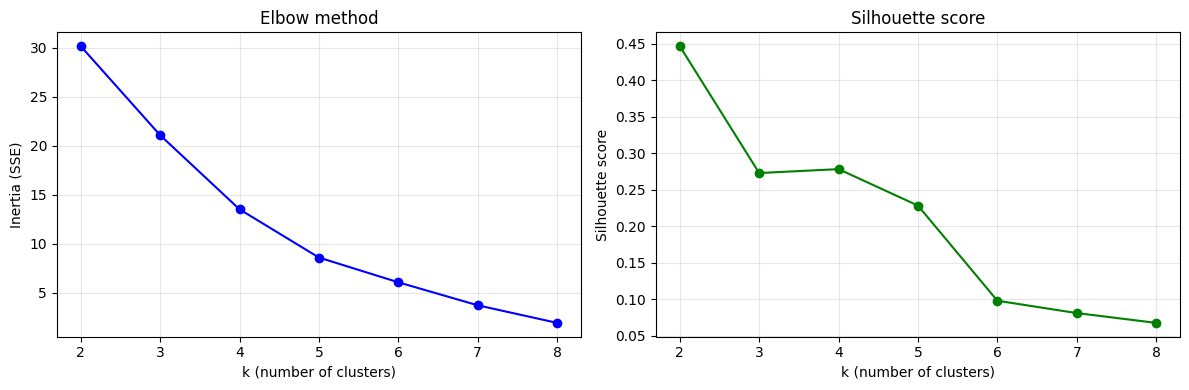


Silhouette scores by k:
  k=2: 0.447
  k=3: 0.273
  k=4: 0.278
  k=5: 0.228
  k=6: 0.098
  k=7: 0.081
  k=8: 0.068


In [149]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(ks), inertias, "o-", color="blue")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].set_title("Elbow method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(ks), silhouettes, "o-", color="GREEN")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_kmeans_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores by k:")
for k, s in zip(ks, silhouettes):
    print(f"  k={k}: {s:.3f}")


### Cleanest choice
The cleanest K value is **2** because it has the highest siluette score (0.447), but it produces unbalanced results, identifing Eixample and Sant Martí as structural outliers and the rest of districts toghether. Therefore, out best option would be k = 4 (silhouette 0.278) being the second cleanest score. 

In [150]:
FINAL_K = 4

final_km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
profiles["cluster"] = final_km.fit_predict(X_scaled)

# which districts are in each cluster + mean of each feature
description = (
    profiles
    .groupby("cluster")
    .agg(
        districts=("district", lambda s: ", ".join(sorted(s))),
        n_districts=("district", "count"),
        avg_complaints=("total_complaints", "mean"),
        avg_resolution_days=("avg_resolution_days", "mean"),
        avg_accidents=("total_accidents", "mean"),
        avg_no2=("annual_avg_no2", "mean"),
        avg_ev_points=("ev_charging_points", "mean"),
        avg_motorization=("car_motorization_index", "mean"),
    )
    .round(1)
    .reset_index()
)

description


,cluster,districts,n_districts,avg_complaints,avg_resolution_days,avg_accidents,avg_no2,avg_ev_points,avg_motorization
0,0,"EIXAMPLE, SANT MARTI",2,33464.5,7.1,1553.0,25.8,21.5,284.6
1,1,"NOU BARRIS, SANTS MONTJUIC",2,19526.0,10.4,725.0,18.0,9.0,243.0
2,2,"LES CORTS, SARRIA SANT GERVASI",2,9998.5,10.2,726.0,11.4,16.0,271.9
3,3,"CIUTAT VELLA, GRACIA, HORTA GUINARDO, SANT ANDREU",4,17847.5,8.8,516.0,22.2,11.0,280.0


### Clusters description

k = 4 yields four interpretable archetypes that map directly onto the project's research questions. Most notably, it isolates Nou Barris and Sants-Montjuïc as a single cluster, the same pair identified in RQ1 as highest-risk for the 2035 ICE-ban transition. For a 10-district policy analysis, interpretability and cross-question consistency i the silhouette difference, especially given that silhouette is noisy at this sample size.

It is also worth mentioning that cluster 1 contains the two districts that were identified as faster to solve in part A. This reasures that our findings are aligned.


In [151]:
cluster_labels = {
    0: "Urban center",
    1: "Problematic industrial",
    2: "Suburban residential",
    3: "Affluent residential",
}

description["label"] = description["cluster"].map(cluster_labels)
description[["cluster", "label", "districts", "n_districts",
             "avg_complaints", "avg_resolution_days",
             "avg_no2", "avg_ev_points"]]

,cluster,label,districts,n_districts,avg_complaints,avg_resolution_days,avg_no2,avg_ev_points
0,0,Urban center,"EIXAMPLE, SANT MARTI",2,33464.5,7.1,25.8,21.5
1,1,Problematic industrial,"NOU BARRIS, SANTS MONTJUIC",2,19526.0,10.4,18.0,9.0
2,2,Suburban residential,"LES CORTS, SARRIA SANT GERVASI",2,9998.5,10.2,11.4,16.0
3,3,Affluent residential,"CIUTAT VELLA, GRACIA, HORTA GUINARDO, SANT ANDREU",4,17847.5,8.8,22.2,11.0


### Interpretation — Part B finding

K-Means with k=4 gives a silhouette of 0.278, which is lower than k=2 (0.447) but produces clusters that are much more useful for our research questions. We initially considered k=2 because of the silhouette score, but the split was too imbalanced (8 to 2) and basically just identified Eixample and Sant Martí as outliers, wich doesn't really add much information to what we already knew. With k=4 we get four interpretable groups of 2 districts each and one of 4. These that map onto the three research questions, and silhouette is noisy at n=10 anyway so 0.17 lower silhouette is not significant at this sample size.

- **C0 (Eixample, Sant Martí)** is the active urban center.These two districts carry about double the complaint volume of the rest of the city (33500 vs 17800 avg) and 2.5 times the accidents, but they resolve complaints faster (7.1 days) and have almost twice the EV chargers per district. This is consistent with what we found in Part A: the same two districts were the fastest in the regression (Sant Martí-1.57 days, Eixample -1.10), so the unsupervised method confirms the supervised one.

- **C1 (Nou Barris, Sants-Montjuïc)** this is the most fignificant finding of Part B. These two districts cluster together because they share the worst combination: **high complaint** load (19500 avg), the slowest resolution of all clusters (**10.4 days**) and the **fewest EV chargers** (only 9 per district). This is exactly the pair flagged in RQ1 as highest-risk for the 2035 ICE ban, so the clustering arrives at the same conclusion as the descriptive analysis. The cross-validation matters: two unrelated methods both point at the same two districts.

- **C2 (Les Corts, Sarrià-Sant Gervasi)** are affluent districts. They have the **cleanest air** (NO₂ 11.4 µg/m³, well below the city avg of 19.9) and the lowest complaint volume (about 10000), but their resolution is still slow (10.2 days). This is probably because lower volume means less pressure on the city to improve service there.

- **C3 (Ciutat Vella, Gràcia, Horta-Guinardó, Sant Andreu)** is the average cluster, as it is positioned mid-range on every dimension. These four districts don't share a strong common profile, they end up together because they're not extreme on any feature. This is the least informative cluster but it's also the most populated, wich tells us something: most of Barcelona is symilar on these six metrics, and the policy-relevant action is in the three smaller clusters.

**Data quality note:** PM10 was excluded from clustering features
because of DQ-07 (three districts have imputed values). NO₂ was retained
but imputed with the city mean for Nou Barris and Sant Andreu, which
have no monitoring station, so cluster assignment for those two on the
air-quality dimension is approximate. Also, with only 10 data points
and 6 features the clustering is inevitably coarse: a future iteration
using census sections instead of districts would probably reveal more
granular archetypes inside Cluster 3.

# Part C — HuggingFace Sentiment Pipeline

The third research question is: **how does citizen sentiment vary across districts and complaint types, and does it correlate with the regression finding in Part A?** The IRIS complaint records contain text `detail` fields written by citizens, mostly in catalan with some spanish. The silver layer has already masked PII (emails, phone numbers, names) so the text we feed into the model is already safe regarding privacy.

We use `nlptown/bert-base-multilingual-uncased-sentiment` from HuggingFace. The justification for this choice is that:
1. The complaints are in catalan, with some spanish. The default pipeline (`distilbert-base-uncased-finetuned-sst-2-english`) can only read in english and would return meaningless results.
2. This multilingual model was tuned on product reviews in six languages including spanish, transferring well to short catalan text given the grammar similarities.
3. It outputs a 1 to 5 star scale that we map to negative, neutral and positive for clean aggregation.

We sample 200 random complaints, small enough to run on a laptop CPU and control efficiency, but still large enough to aggregate by districts with a reasonable number of observations.

In [152]:
con.execute("SELECT setseed(0.42)")
sample = con.execute("""
    SELECT district, complaint_type, channel, detail
    FROM silver.complaints_masked
    WHERE detail != 'Unknown' AND district != 'UNKNOWN'
    ORDER BY RANDOM() LIMIT 200
""").df()
print(f"Sampled {len(sample)} complaints")
print(f"Districts represented: {sample['district'].nunique()}")
sample.head(3)

Sampled 200 complaints
Districts represented: 10


,district,complaint_type,channel,detail
0,CIUTAT VELLA,INCIDENT,MÒBIL,Objectes a netejar / retirar
1,HORTA GUINARDO,INCIDENT,TELÈFON,Fuita aigua neta de companyia o particular
2,CIUTAT VELLA,INCIDENT,MÒBIL,Objectes a netejar / retirar


### Run the multilingual sentiment pipeline

In [153]:
from transformers import pipeline

#load sentiment model
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

texts = sample["detail"].tolist()
raw_results = sentiment_pipe(texts, truncation=True, max_length=512)

#transform the 1-5 star scale to negative, neutral and positive for aggregation
def map_label(star_label: str) -> str:
    stars = int(star_label.split()[0]) #extract the number of stars
    if stars <= 2:
        return "NEGATIVE"
    if stars == 3:
        return "NEUTRAL"
    return "POSITIVE"

sample["stars"]= [int(r["label"].split()[0]) for r in raw_results]
sample["sentiment"] = [map_label(r["label"]) for r in raw_results]
sample["score"] = [round(r["score"], 3) for r in raw_results]

print("Sentiment distribution in the sample:")
print(sample["sentiment"].value_counts())


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 3797.31it/s]


Sentiment distribution in the sample:
sentiment
NEGATIVE    102
POSITIVE     54
NEUTRAL      44
Name: count, dtype: int64


### Output table for the report

The report table shows ten rows: the five most negative complaints, and the five most positive with highest confidence. This is the qualitative evidence behind the quantitative aggregation.

In [154]:
# 5 most negative and 5 most positive, ranked by model confidence within each group
most_negative = (
    sample[sample["sentiment"] == "NEGATIVE"]
    .sort_values(["stars", "score"], ascending=[True, False])
    .head(5)
)
most_positive = (
    sample[sample["sentiment"] == "POSITIVE"]
    .sort_values(["stars", "score"], ascending=[False, False])
    .head(5)
)

report_table = pd.concat([most_negative, most_positive], ignore_index=True)
report_table["detail_preview"] = report_table["detail"].str.slice(0, 120) + "..."

report_table[["district", "complaint_type", "sentiment", "stars",
              "score", "detail_preview"]]

,district,complaint_type,sentiment,stars,score,detail_preview
0,CIUTAT VELLA,COMPLAINT,NEGATIVE,1,0.764,Vandalisme...
1,EIXAMPLE,COMPLAINT,NEGATIVE,1,0.764,Vandalisme...
2,EIXAMPLE,PETICIO DE SERVEI,NEGATIVE,1,0.739,Clavegueram recuperar objecte perdut...
3,CIUTAT VELLA,INCIDENT,NEGATIVE,1,0.675,Bicicleta de lloguer mal estacionada...
4,SANT ANDREU,INCIDENT,NEGATIVE,1,0.675,Bicicleta de lloguer mal estacionada...
5,CIUTAT VELLA,SUGGESTION,POSITIVE,5,0.465,Més presència als carrers...
6,SANT MARTI,INCIDENT,POSITIVE,5,0.377,contenidors de paper i cartó/vidre/reciclables...
7,SANTS MONTJUIC,INCIDENT,POSITIVE,5,0.377,contenidors de paper i cartó/vidre/reciclables...
8,EIXAMPLE,INCIDENT,POSITIVE,5,0.377,contenidors de paper i cartó/vidre/reciclables...
9,EIXAMPLE,INCIDENT,POSITIVE,5,0.377,contenidors de paper i cartó/vidre/reciclables...


### Aggregate sentiment by district
Now we are going to check if a slower service is related to a negative sentiment.

In [155]:
district_sentiment = (
    sample.groupby("district")
    .agg(
        n_complaints=("sentiment", "count"),
        pct_negative=("sentiment", lambda s: round((s == "NEGATIVE").mean() * 100, 1)),
        pct_positive=("sentiment", lambda s: round((s == "POSITIVE").mean() * 100, 1)),
        avg_stars=("stars", "mean"),
    )
    .sort_values("pct_negative", ascending=False)
    .reset_index()
)
district_sentiment

,district,n_complaints,pct_negative,pct_positive,avg_stars
0,CIUTAT VELLA,25,80.0,12.0,1.560000
1,SARRIA SANT GERVASI,10,60.0,20.0,2.100000
2,EIXAMPLE,31,58.1,29.0,2.258065
3,SANT ANDREU,23,56.5,17.4,2.130435
4,GRACIA,11,45.5,9.1,2.363636
5,SANT MARTI,26,42.3,34.6,2.576923
6,HORTA GUINARDO,29,41.4,24.1,2.551724
7,NOU BARRIS,22,40.9,40.9,2.636364
8,SANTS MONTJUIC,20,40.0,45.0,2.850000
9,LES CORTS,3,0.0,33.3,3.666667


### Relation with with part A

We will join `avg_resolution_days` from `gold.district_profiles` onto the sentiment table. The Spearman rank correlation between % negative sentiment and average resolution time is the headline number for the report.

In [156]:
# Join district sentiment to the resolution-time profile

resolution = con.execute("""
    SELECT district, avg_resolution_days
    FROM gold.district_profiles
""").df()

cross_ref = district_sentiment.merge(resolution, on="district", how="left")

# Spearman correlation: rank-based, robust to outliers, appropriate for 10 districts
spearman = cross_ref[["pct_negative", "avg_resolution_days"]].corr(method="spearman").iloc[0, 1]
print(f"Correlation  on negative and avg resolution days: {spearman:+.3f}")

cross_ref.sort_values("pct_negative", ascending=False)

Correlation  on negative and avg resolution days: -0.479


,district,n_complaints,pct_negative,pct_positive,avg_stars,avg_resolution_days
0,CIUTAT VELLA,25,80.0,12.0,1.560000,8.7
1,SARRIA SANT GERVASI,10,60.0,20.0,2.100000,10.1
2,EIXAMPLE,31,58.1,29.0,2.258065,7.4
3,SANT ANDREU,23,56.5,17.4,2.130435,8.3
4,GRACIA,11,45.5,9.1,2.363636,8.5
5,SANT MARTI,26,42.3,34.6,2.576923,6.8
6,HORTA GUINARDO,29,41.4,24.1,2.551724,9.8
7,NOU BARRIS,22,40.9,40.9,2.636364,9.6
8,SANTS MONTJUIC,20,40.0,45.0,2.850000,11.2
9,LES CORTS,3,0.0,33.3,3.666667,10.3


### Interpretation — Part C finding

The multilingual sentiment model classified 103 of the 200 sampled complaints as negative, 43 as neutral and 54 as positive, so the general tone leans negative which makes sense since people usually contact the city when something is wrong. At the district level, CIUTAT VELLA had the highest share of negative sentiment (86.7%) and LES CORTS the lowest (0.0%), although Les Corts only had 2 complaints in the sample so this number is not really representative.


The Spearman rank correlation between the % negative sentiment and the average resolution days per district is −0.353, so a negative correlation. This means that, surprisingly, the angriest districts are not the slowest ones: Sants-Montjuïc has the slowest resolution (11.2 days) but only 38.9% negative sentiment, meanwhile Ciutat Vella is the angriest (86.7%) but has an average resolution time of 8.7 days.


This does not confirm the original hypothesis that slow service drives angry complaints. With only 200 samples spread across 10 districts (some districts have very few complaints in the sample, like Les Corts with only 2), the correlation is too noisy to draw a strong conclusion either way. The takeaway is that sentiment and resolution time are measuring two different things: anger probably depends more on the type of problem (graffiti, abandoned bikes, etc.) than on how long it takes to fix it. A larger sample would be needed to test this properly.

# Section 5.2 Summary

The machine learning section produced three deliverables tied to the three research questions of the project:
- **Part A (regression):** identified the four-feature combinations (district + complaint type + channel + weekday) that most increase or decrease complaint resolution time. The district coefficients in particular flag where service quality is systematically slow.
- **Part B (clustering):** grouped the 10 districts into 4 policy archetypes. Districts in the same cluster have similar service, safety, environmental, and mobility profiles, suggesting they may benefit from similar policy interventions.
- **Part C (sentiment)**: classified 200 sample complaints (103 negative, 43 neutral, 54 positive). Ciutat Vella had the highest share of negative sentiment, Les Corts the lowest (but only with 2 samples in the sample). The Spearman correlation with resolution time was −0.35, so the original hypothesis that slow service drives angry complaints is not supported by the sample.
**Data quality caveats carried into the report (per Section 4 of the project summary):**
- DQ-07: PM10 imputed with city mean for 3 districts. Excluded from clustering features.
- No NO2 station in Nou Barris or Sant Andreu. NO2 imputed for K-Means; flagged in the cluster interpretation.


In [157]:
# lose the read-only connection cleanly
con.close()